In [1]:
import os.path

import numpy as np
import pandas as pd

from dataclasses import dataclass

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment

import hdbscan

## 1. 数据输入

In [2]:
DATA_PATH = "./students003.txt"
OUT_PATH = "./output"

In [3]:
def load_data(data_path=None):
    assert data_path is not None, "Please provide a valid data path"
    df = pd.read_csv(
        data_path,
        sep="\t",
        names=["time", "id", "x", "y"],
        dtype={"time": int, "id": int, "x": float, "y": float},
    )
    return df

df = load_data(DATA_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17953 entries, 0 to 17952
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    17953 non-null  int64  
 1   id      17953 non-null  int64  
 2   x       17953 non-null  float64
 3   y       17953 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 561.2 KB


## 2. 预处理与速度特征

In [4]:
def add_velocity_features(df):
    df = df.copy()
    df = df.sort_values(["id", "time"]).reset_index(drop=True)
    df["vx"] = df.groupby("id")["x"].diff().fillna(0.0)
    df["vy"] = df.groupby("id")["y"].diff().fillna(0.0)
    return df

df = add_velocity_features(df)
df.head()

,time,id,x,y,vx,vy
0,0,1,9.050000,6.038093,0.000000,0.000000
1,10,1,9.425469,6.115419,0.375470,0.077326
2,20,1,9.800939,6.192983,0.375470,0.077564
3,30,1,10.176199,6.270309,0.375259,0.077326
4,40,1,10.563454,6.360284,0.387256,0.089975


## 3. 参数配置

In [5]:
@dataclass
class ClusterConfig:
    alpha: float = 5.0
    use_hdbscan: bool = True
    hdbscan_min_cluster_size: int = 3
    hdbscan_min_samples: int = 2
    dbscan_eps: float = 0.8
    dbscan_min_samples: int = 3
    min_groups_per_frame: int = 2
    match_lambda: float = 2.0
    match_threshold: float = 10.0

CFG = ClusterConfig()
CFG

ClusterConfig(alpha=5.0, use_hdbscan=True, hdbscan_min_cluster_size=3, hdbscan_min_samples=2, dbscan_eps=0.8, dbscan_min_samples=3, min_groups_per_frame=2, match_lambda=2.0, match_threshold=10.0)

## 4. 单帧聚类

In [6]:
def cluster_single_frame(frame, cfg):
    frame = frame.copy().reset_index(drop=True)

    X = frame[["x", "y", "vx", "vy"]].to_numpy(dtype=float)
    X[:, 2:] *= cfg.alpha
    X = StandardScaler().fit_transform(X)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=cfg.hdbscan_min_cluster_size,
        min_samples=cfg.hdbscan_min_samples
    )
    labels = clusterer.fit_predict(X)

    frame["local_cluster"] = labels

    clusters = []
    for cid in sorted(set(labels)):
        if cid == -1:
            continue
        members = frame[frame["local_cluster"] == cid]
        clusters.append({
            "local_id": int(cid),
            "pos": members[["x", "y"]].mean().to_numpy(),
            "vel": members[["vx", "vy"]].mean().to_numpy(),
            "size": int(len(members)),
        })

    return frame, clusters

In [7]:
def force_make_two_clusters(frame, cfg):
    frame = frame.copy().reset_index(drop=True)

    if len(frame) < 2:
        frame["local_cluster"] = 0
        clusters = [{
            "local_id": 0,
            "pos": frame[["x", "y"]].mean().to_numpy(),
            "vel": frame[["vx", "vy"]].mean().to_numpy(),
            "size": int(len(frame)),
        }]
        return frame, clusters

    X = frame[["x", "y", "vx", "vy"]].to_numpy(dtype=float)
    X[:, 2:] *= cfg.alpha
    X = StandardScaler().fit_transform(X)

    km = KMeans(n_clusters=2, n_init="auto", random_state=42)
    labels = km.fit_predict(X)
    frame["local_cluster"] = labels

    clusters = []
    for cid in sorted(set(labels)):
        members = frame[frame["local_cluster"] == cid]
        clusters.append({
            "local_id": int(cid),
            "pos": members[["x", "y"]].mean().to_numpy(),
            "vel": members[["vx", "vy"]].mean().to_numpy(),
            "size": int(len(members)),
        })

    return frame, clusters

In [8]:
def ensure_minimum_clusters(frame, clusters, cfg):
    if len(clusters) >= cfg.min_groups_per_frame:
        return frame, clusters

    frame2, clusters2 = force_make_two_clusters(frame, cfg)
    if len(clusters2) >= cfg.min_groups_per_frame:
        return frame2, clusters2

    frame2 = frame.copy().reset_index(drop=True)
    frame2["local_cluster"] = 0
    clusters2 = [{
        "local_id": 0,
        "pos": frame2[["x", "y"]].mean().to_numpy(),
        "vel": frame2[["vx", "vy"]].mean().to_numpy(),
        "size": int(len(frame2)),
    }]
    return frame2, clusters2

## 5. 跨帧匹配

In [9]:
def match_clusters(prev_states, prev_group_ids, cur_clusters, cfg):
    assignment = {}

    if len(prev_group_ids) == 0 or len(cur_clusters) == 0:
        return assignment, None, set(), set()

    cost = np.zeros((len(prev_group_ids), len(cur_clusters)), dtype=float)

    for i, gid in enumerate(prev_group_ids):
        prev_pos, prev_vel = prev_states[gid]
        for j, cl in enumerate(cur_clusters):
            dp = np.linalg.norm(prev_pos - cl["pos"])
            dv = np.linalg.norm(prev_vel - cl["vel"])
            cost[i, j] = dp + cfg.match_lambda * dv

    row_ind, col_ind = linear_sum_assignment(cost)

    matched_cur = set()
    matched_prev = set()

    for i, j in zip(row_ind, col_ind):
        if cost[i, j] <= cfg.match_threshold:
            gid = prev_group_ids[i]
            cid = cur_clusters[j]["local_id"]
            assignment[cid] = gid
            matched_cur.add(cid)
            matched_prev.add(gid)

    return assignment, cost, matched_cur, matched_prev

In [10]:
def process_all_frames(df, cfg):
    df = df.copy()
    df = df.sort_values(["time", "id"]).reset_index(drop=True)

    output_rows = []
    prev_states = {}
    prev_group_ids = []
    next_global_group_id = 0

    for t in sorted(df["time"].unique()):
        frame = df[df["time"] == t].copy().reset_index(drop=True)

        clustered_frame, clusters = cluster_single_frame(frame, cfg)
        clustered_frame, clusters = ensure_minimum_clusters(clustered_frame, clusters, cfg)

        cur_assignment = {}

        if len(prev_group_ids) == 0:
            for cl in clusters:
                cur_assignment[cl["local_id"]] = next_global_group_id
                next_global_group_id += 1
        else:
            assignment, cost, matched_cur, matched_prev = match_clusters(
                prev_states=prev_states,
                prev_group_ids=prev_group_ids,
                cur_clusters=clusters,
                cfg=cfg,
            )
            cur_assignment.update(assignment)

            for cl in clusters:
                cid = cl["local_id"]
                if cid not in cur_assignment:
                    cur_assignment[cid] = next_global_group_id
                    next_global_group_id += 1

        for _, row in clustered_frame.iterrows():
            local_id = int(row["local_cluster"])
            group_id = -1 if local_id == -1 else cur_assignment[local_id]
            output_rows.append({
                "time": int(row["time"]),
                "id": int(row["id"]),
                "group_id": int(group_id),
            })

        prev_states = {}
        prev_group_ids = []
        for cl in clusters:
            gid = cur_assignment[cl["local_id"]]
            prev_states[gid] = (cl["pos"], cl["vel"])
            prev_group_ids.append(gid)

    result = pd.DataFrame(output_rows).sort_values(["time", "id"]).reset_index(drop=True)
    return result

result_df = process_all_frames(df, CFG)
result_df.head(20)

,time,id,group_id
0,0,1,2
1,0,2,3
2,0,3,2
3,0,4,1
4,0,5,3
5,0,6,-1
6,0,7,-1
7,0,8,-1
8,0,9,3
9,0,10,1


## 6. 输出检查

In [11]:
group_counts = result_df[result_df["group_id"] >= 0].groupby("time")["group_id"].nunique()
group_counts.head(10)

time
0     5
10    5
20    5
30    5
40    5
50    5
60    4
70    6
80    7
90    5
Name: group_id, dtype: int64

In [12]:
result_df.head(30)

,time,id,group_id
0,0,1,2
1,0,2,3
2,0,3,2
3,0,4,1
4,0,5,3
5,0,6,-1
6,0,7,-1
7,0,8,-1
8,0,9,3
9,0,10,1


## 7. 可视化（可选）

In [30]:
import matplotlib.pyplot as plt

def plot_frame(result, original, time_value, x_range:tuple[float,float]|None=None, y_range:tuple[float,float]|None=None, save_to_file=False):

    # clear previous plot
    plt.clf()

    merged = original.merge(result, on=["time", "id"], how="left")
    frame = merged[merged["time"] == time_value].copy()

    plt.figure(figsize=(7, 5))
    for gid in sorted(frame["group_id"].unique()):
        sub = frame[frame["group_id"] == gid]
        if gid == -1:
            plt.scatter(sub["x"], sub["y"], label="ungrouped", s=20, color="gray", alpha=0.5)
        else:
            plt.scatter(sub["x"], sub["y"], label=f"group {gid}", s=50)

    if x_range is not None:
        plt.xlim(x_range[0], x_range[1])
    if y_range is not None:
        plt.ylim(y_range[0], y_range[1])
    plt.title(f"Frame {time_value}")
    plt.xlabel("x")
    plt.ylabel("y")
    # try put the legend outside the plot, to the upper right corner

    plt.legend(loc="upper right", bbox_to_anchor=(1.27,1.))
    if save_to_file:
        plt.savefig(os.path.join(OUT_PATH,f"time_{time_value}.png"), bbox_inches="tight")
        plt.clf()
        plt.close()
    else:
        plt.show()

In [24]:
plot_frame(result_df, df, time_value=60)
# df["time"].unique()

<Figure size 640x480 with 0 Axes>

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

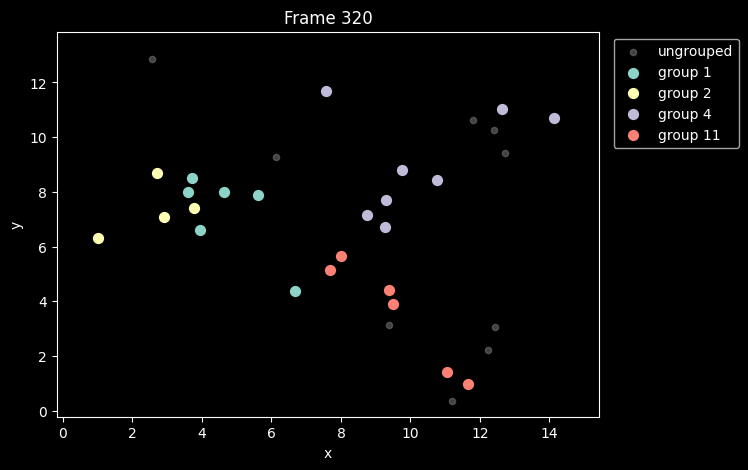

In [31]:
for t in sorted(df["time"].unique())[:50]:
    plot_frame(result_df, df, time_value=t,
            x_range=(df['x'].min(),df['x'].max()),
            y_range=(df['y'].min(),df['y'].max()),
            save_to_file=True)

In [28]:
df['x'].min()

np.float64(-0.174686040989)

## 8. 保存结果

In [ ]:
OUT_CSV = "group_labels.csv"
result_df.to_csv(OUT_CSV, index=False)
OUT_CSV